Using limma for key cluster DEG analysis

In [14]:
library(limma)
library(dplyr)
library(ggplot2)
library(edgeR)
library(stringr)
library(reshape2)
library(ggrepel)

In [15]:
# read the voom normalised data
exp_df <- read.csv('/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/Exp.csv', header = T, row.names = 1)    
head(exp_df)

,A1BG,A1BG.AS1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,AAMDC,⋯,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
127399,1.33585123,2.837184,-0.4757615,3.522372,5.289224,5.436261,1.912285,6.170977,5.486915,5.2589014,⋯,6.255815,7.125433,0.9700382,3.911810,3.513628,3.6713206,5.387186,7.657886,4.690012,5.671180
143B,0.50502144,1.146315,4.0206406,2.191379,5.726666,3.992820,3.975156,6.908841,4.667542,2.9568233,⋯,7.219736,7.134179,1.4876841,4.076379,4.290047,3.9134273,4.413880,7.452491,5.690861,6.489629
170MGBA,-6.34365096,-1.951334,7.9345323,3.568739,4.676171,4.810112,2.668508,6.323091,6.443912,3.2753462,⋯,5.663259,4.028126,2.9669618,4.290252,4.614660,-7.9286135,6.486930,7.582614,6.399150,7.430827
22RV1,-0.05089222,2.802209,2.9740419,-2.257672,6.130935,6.428204,3.251642,6.020554,6.088325,0.6373114,⋯,6.658125,7.350443,1.1318189,3.456761,4.554439,-1.2478247,5.552063,4.451671,5.854928,5.957179
2313287,-4.77226339,-1.602338,-4.7722634,1.264826,5.211839,4.931832,-4.241749,6.394806,5.462554,2.0450756,⋯,6.162984,6.500690,1.9419821,4.451470,4.655631,-3.8547255,5.514551,5.788176,5.886246,6.400234
253J,0.40139481,1.527828,-2.0953405,3.717680,6.460873,5.066240,-4.808059,7.432302,6.160688,2.4514232,⋯,5.223987,6.001888,3.9187273,4.247525,4.068799,0.6909014,4.730023,7.069439,6.007592,5.257582


Using the optuna results

In [16]:
metadata_df <- read.csv('/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Code/Daporinad_NAMPT_fullres_optuna.csv', 
      header = T, row.names = 1)
head(metadata_df)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,⋯,X13,X14,X15,actual_dep_NAMPT,actual_IC50,pred_dep_NAMPT,pred_IC50,Set,Benefit_Score,Cluster
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>
SKUT1,39.86891,-50.41921,-38.58407,-167.2582,79.38719,-132.15709,-62.25644,-119.67266,-29.845329,36.36774,⋯,-118.08230,-9.320492,-95.72754,0.10425760,-7.85159,-2.1129663,0.1768294,Train,-2.289796,13
HUCCT1,-54.39693,31.60342,-99.97849,-177.9153,81.74341,-99.60592,-29.44188,-84.71657,-14.507680,100.58463,⋯,-128.80430,-32.948534,-106.70543,0.19662958,-4.09954,-1.6380331,6.3084373,Train,-7.946470,21
HS294T,45.74722,-21.12843,-96.12735,-172.7260,26.69720,-127.31486,-55.86482,-113.40806,-5.551791,100.83024,⋯,-119.62224,-21.739093,-122.99815,0.02802041,-2.45927,-2.1063982,4.1774419,Train,-6.283840,2
NCIH1437,-42.83307,-54.12377,-95.42673,-129.2803,109.57688,-86.92853,-20.69419,-87.58640,-63.597818,129.96071,⋯,-77.88407,3.987170,-115.16706,0.04948346,-4.02209,-1.1798127,1.1965257,Train,-2.376338,20
OVTOKO,5.37140,-50.52679,-42.20664,-120.9439,81.55354,-111.21606,-69.78246,-61.00291,-69.428518,132.76301,⋯,-153.74299,27.229291,-109.69866,0.11308344,-2.23914,-1.3954840,0.7417224,Train,-2.137206,9
MDAMB453,29.39567,-113.51833,-69.09140,-135.8898,98.43003,-79.29166,-31.75587,-73.15525,-18.399742,107.61625,⋯,48.23274,90.061870,-51.59299,0.97938679,-4.05243,-0.2279682,6.3834938,Train,-6.611462,29


In [17]:
# generate count matrices
exp_df <- t(exp_df)
exp_df <- exp_df[, rownames(metadata_df)]
head(exp_df)

,SKUT1,HUCCT1,HS294T,NCIH1437,OVTOKO,MDAMB453,ISTMES1,PC14,CFPAC1,OE33,⋯,SKNDZ,SNU1105,KIJK,NH12,MDAMB436,HCC1143,MCF7,CCK81,OVCAR8,NCIH1650
A1BG,-2.205070,-5.573467,3.8205812,-1.0638131,-0.5962334,3.156887,-3.5604921,-1.3534712,-3.720233,-5.400753,⋯,1.397337,2.9256406,2.623742,1.438818,2.306530,0.584609,2.0897787,-3.3990128,2.212848,2.461567
A1BG.AS1,-1.040683,-1.486004,4.1969904,0.1296158,1.3693331,3.653845,-0.5519301,0.4091593,-1.242186,-3.564252,⋯,1.823019,3.6536064,3.086378,2.693831,3.037932,2.679912,3.0227729,-0.8051721,3.140918,2.884565
A2M,-1.989802,-2.469130,7.6515715,-3.1544156,-4.7391914,-3.081136,-3.8653467,-2.5514106,-2.903097,-2.593399,⋯,-1.572044,-0.4710894,-2.282080,-6.994420,-1.325098,-5.325712,-0.6551797,-2.0453758,-2.337205,-3.707615
A4GALT,2.881905,2.745754,0.3367438,2.7372556,3.1562997,-5.403064,1.3981297,2.9366658,3.591785,3.994322,⋯,-3.252426,1.6598800,-4.073493,-6.257454,4.222716,4.081555,5.2269457,-2.0041532,2.524034,3.620644
AAAS,5.440526,4.801790,5.6211539,6.2084211,5.9039633,5.528412,5.3647444,5.4715011,5.425032,5.284120,⋯,6.130004,5.0147517,5.295349,6.588781,4.781507,4.982139,5.9185276,5.4271826,5.946301,4.927532
AACS,5.887808,5.204117,6.0382988,5.1786569,5.8218844,6.189487,5.7624018,5.7778361,5.213176,5.754155,⋯,5.344337,5.1269958,5.085408,4.977723,6.077816,4.855440,6.3505933,6.1847665,5.481613,5.315061


In [18]:
head(metadata_df)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,⋯,X13,X14,X15,actual_dep_NAMPT,actual_IC50,pred_dep_NAMPT,pred_IC50,Set,Benefit_Score,Cluster
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>
SKUT1,39.86891,-50.41921,-38.58407,-167.2582,79.38719,-132.15709,-62.25644,-119.67266,-29.845329,36.36774,⋯,-118.08230,-9.320492,-95.72754,0.10425760,-7.85159,-2.1129663,0.1768294,Train,-2.289796,13
HUCCT1,-54.39693,31.60342,-99.97849,-177.9153,81.74341,-99.60592,-29.44188,-84.71657,-14.507680,100.58463,⋯,-128.80430,-32.948534,-106.70543,0.19662958,-4.09954,-1.6380331,6.3084373,Train,-7.946470,21
HS294T,45.74722,-21.12843,-96.12735,-172.7260,26.69720,-127.31486,-55.86482,-113.40806,-5.551791,100.83024,⋯,-119.62224,-21.739093,-122.99815,0.02802041,-2.45927,-2.1063982,4.1774419,Train,-6.283840,2
NCIH1437,-42.83307,-54.12377,-95.42673,-129.2803,109.57688,-86.92853,-20.69419,-87.58640,-63.597818,129.96071,⋯,-77.88407,3.987170,-115.16706,0.04948346,-4.02209,-1.1798127,1.1965257,Train,-2.376338,20
OVTOKO,5.37140,-50.52679,-42.20664,-120.9439,81.55354,-111.21606,-69.78246,-61.00291,-69.428518,132.76301,⋯,-153.74299,27.229291,-109.69866,0.11308344,-2.23914,-1.3954840,0.7417224,Train,-2.137206,9
MDAMB453,29.39567,-113.51833,-69.09140,-135.8898,98.43003,-79.29166,-31.75587,-73.15525,-18.399742,107.61625,⋯,48.23274,90.061870,-51.59299,0.97938679,-4.05243,-0.2279682,6.3834938,Train,-6.611462,29


In [19]:
metadata_df$benefit_score_scaled <- as.numeric(scale(metadata_df$Benefit_Score))

In [20]:
# get clusters 9,29 and 24 as the key_cluster
metadata_df$keyCluster <- ifelse(metadata_df$Cluster %in% c(8,10),yes = 'key_cluster', no= 'nonKey_cluster')
metadata_df$keyCluster <- factor(metadata_df$keyCluster, levels = c('nonKey_cluster', 'key_cluster'))

In [21]:
table(metadata_df$keyCluster)


nonKey_cluster    key_cluster 
           594             53 

In [22]:
table(metadata_df$susceptibility_cat)

< table of extent 0 >

In [23]:
sum(is.na(metadata_df$Cluster))

[1] 0

In [24]:
median_score <- median(metadata_df$benefit_score_scaled)
metadata_df$Benefit_Score_cat <- ifelse(metadata_df$benefit_score_scaled >= median_score,
    'high_score', 'low_score')
metadata_df$Benefit_Score_cat <- factor(metadata_df$Benefit_Score_cat, levels = c('low_score', 'high_score'))
# metadata_df$susceptibility_cat <- factor(metadata_df$susceptibility_cat, levels = c('non-key cluster', 'resistant', 'susceptible'))
head(metadata_df)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,⋯,actual_dep_NAMPT,actual_IC50,pred_dep_NAMPT,pred_IC50,Set,Benefit_Score,Cluster,benefit_score_scaled,keyCluster,Benefit_Score_cat
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<dbl>,<fct>,<fct>
SKUT1,39.86891,-50.41921,-38.58407,-167.2582,79.38719,-132.15709,-62.25644,-119.67266,-29.845329,36.36774,⋯,0.10425760,-7.85159,-2.1129663,0.1768294,Train,-2.289796,13,0.2769233,nonKey_cluster,high_score
HUCCT1,-54.39693,31.60342,-99.97849,-177.9153,81.74341,-99.60592,-29.44188,-84.71657,-14.507680,100.58463,⋯,0.19662958,-4.09954,-1.6380331,6.3084373,Train,-7.946470,21,-0.8264083,nonKey_cluster,low_score
HS294T,45.74722,-21.12843,-96.12735,-172.7260,26.69720,-127.31486,-55.86482,-113.40806,-5.551791,100.83024,⋯,0.02802041,-2.45927,-2.1063982,4.1774419,Train,-6.283840,2,-0.5021131,nonKey_cluster,low_score
NCIH1437,-42.83307,-54.12377,-95.42673,-129.2803,109.57688,-86.92853,-20.69419,-87.58640,-63.597818,129.96071,⋯,0.04948346,-4.02209,-1.1798127,1.1965257,Train,-2.376338,20,0.2600432,nonKey_cluster,high_score
OVTOKO,5.37140,-50.52679,-42.20664,-120.9439,81.55354,-111.21606,-69.78246,-61.00291,-69.428518,132.76301,⋯,0.11308344,-2.23914,-1.3954840,0.7417224,Train,-2.137206,9,0.3066858,nonKey_cluster,high_score
MDAMB453,29.39567,-113.51833,-69.09140,-135.8898,98.43003,-79.29166,-31.75587,-73.15525,-18.399742,107.61625,⋯,0.97938679,-4.05243,-0.2279682,6.3834938,Train,-6.611462,29,-0.5660156,nonKey_cluster,low_score


In [25]:
# table(metadata_df$keyCluster, metadata_df$susceptibility_cat)

In [26]:
metadata_df$Cluster <- as.factor(metadata_df$Cluster)
metadata_df$Set <- as.factor(metadata_df$Set)

In [28]:
design_mat <- model.matrix(~ keyCluster + Benefit_Score_cat, data = metadata_df)

In [29]:
dim(design_mat)

[1] 647   3

In [30]:
dim(exp_df)

[1] 16289   647

In [31]:
fit <- lmFit(exp_df, design_mat)
fit2 <- eBayes(fit, trend = TRUE)

In [32]:
topTable(fit2, coef = "keyClusterkey_cluster", number = 10)

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TJP1,-7.445249,6.01440544,-31.72665,5.739472e-134,9.349026e-130,295.1285
SEPTIN10,-7.104150,5.35002642,-30.13465,2.489744e-125,2.027772e-121,275.3651
NCKAP1,-5.355830,7.38790237,-29.26726,1.367787e-120,7.426626e-117,264.5172
TEAD1,-6.612842,6.51993219,-29.17242,4.524184e-120,1.842361e-116,263.3281
NLRC3,5.103630,0.02553922,28.80957,4.418661e-118,1.439511e-114,258.7737
BCAR1,-5.482569,5.68455843,-27.47583,9.642998e-111,2.617913e-107,241.9731
PTPN21,-5.960817,3.52800923,-27.20117,3.158995e-109,7.350980e-106,238.5037
BTK,8.278465,-1.96471287,26.98277,5.072590e-108,1.032843e-104,235.7432
SOWAHC,-6.838466,3.85378539,-26.93419,9.408228e-108,1.702785e-104,235.1290


In [33]:
res <- topTable(fit2, coef = "keyClusterkey_cluster", number = Inf)
res %>%
  filter(abs(logFC) > 1 & adj.P.Val < 0.05) %>%
  dim()

[1] 4421    6

In [41]:
write.csv(res, file = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/Daporinad_NAMPT_depMap_keyCluster_deg_optuna.csv')

In [ ]:
#saveRDS(fit2,file = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/Daporinad_NAMPT_depMap_keyCluster_deg_fit_optuna.RDS')

In [34]:
df <- res %>%
  filter(!is.na(logFC), !is.na(adj.P.Val))
df$gene <- rownames(df)
# Create a column for significance
df <- df %>%
  mutate(
    sig = case_when(
      adj.P.Val < 0.01 & logFC > 1 ~ "Upregulated",
      adj.P.Val < 0.01 & logFC < -1 ~ "Downregulated",
      TRUE ~ "Non-significant"
    )
  )

# Identify top 10 upregulated and downregulated genes
top_up <- df %>%
  filter(sig == "Upregulated") %>%
  top_n(10, logFC)

top_down <- df %>%
  filter(sig == "Downregulated") %>%
  top_n(-10, logFC)

top_genes <- bind_rows(top_up, top_down)
top_gene_list <- rownames(top_genes)

In [35]:
length(top_gene_list)


[1] 20

In [36]:
head(df)

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene,sig
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
TJP1,-7.445249,6.01440544,-31.72665,5.739472e-134,9.349026e-130,295.1285,TJP1,Downregulated
SEPTIN10,-7.104150,5.35002642,-30.13465,2.489744e-125,2.027772e-121,275.3651,SEPTIN10,Downregulated
NCKAP1,-5.355830,7.38790237,-29.26726,1.367787e-120,7.426626e-117,264.5172,NCKAP1,Downregulated
TEAD1,-6.612842,6.51993219,-29.17242,4.524184e-120,1.842361e-116,263.3281,TEAD1,Downregulated
NLRC3,5.103630,0.02553922,28.80957,4.418661e-118,1.439511e-114,258.7737,NLRC3,Upregulated
BCAR1,-5.482569,5.68455843,-27.47583,9.642998e-111,2.617913e-107,241.9731,BCAR1,Downregulated


In [37]:
df['NAMPT', ]

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene,sig
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
NAMPT,-0.407409,6.964996,-2.333245,0.01994068,0.03074723,-4.836988,NAMPT,Non-significant


EGFR is significantly upregulated among the key clusters, implying its active biological role

In [38]:
df$gene <- rownames(df)
df$top_gene <- ifelse(df$gene %in% top_gene_list, df$gene, NA)

In [39]:
P <- ggplot(df, aes(x = logFC, y = -log10(adj.P.Val), color = sig)) +
  geom_point() +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black", linewidth = 0.25) +
  geom_hline(yintercept = -log10(0.01), linetype = "dashed", color = "black", linewidth = 0.25) +
  geom_text_repel(
    data = df,
    aes(x = logFC, y = -log10(adj.P.Val), label = top_gene),
    size = 4,
    color = "black",
    box.padding = 0.5,
    max.overlaps = 50
  ) +
  scale_color_manual(
    values = c(
      "Downregulated" = "red",
      "Upregulated" = "green",
      "Non-significant" = "grey"
    ),
    na.value = "grey"  # ensures NA gets grey color
  ) +
  labs(
    title = "Key cluster DEG Analysis",
    x = "log2(Fold Change)",
    y = "-log10(Adjusted p-value)"
  ) +
  theme_minimal(base_size = 12) 

Warning message:
“Removed 16269 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


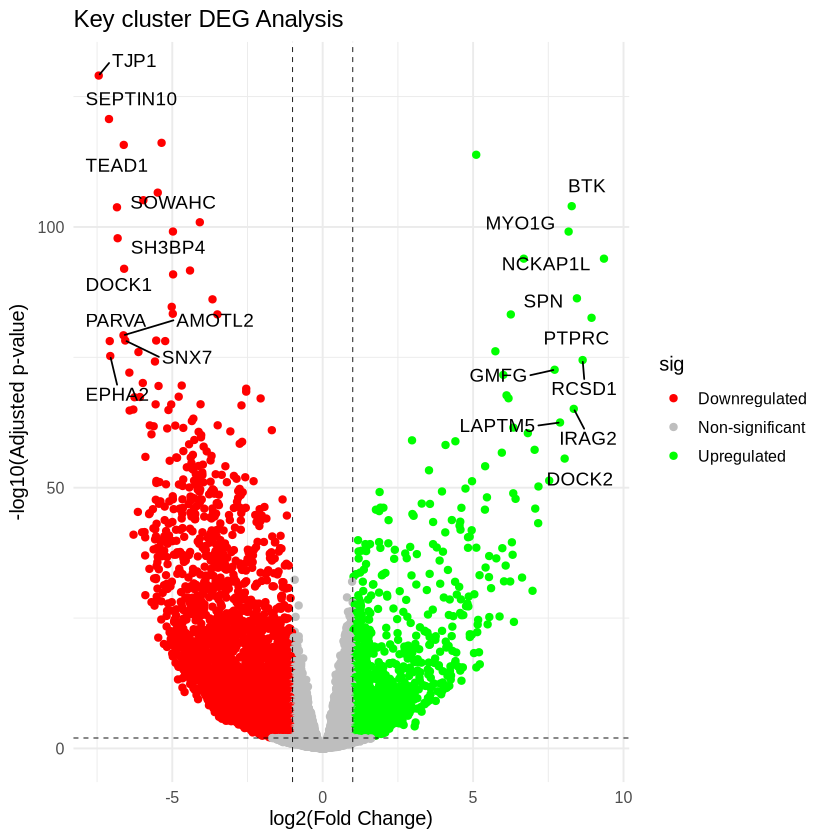

In [40]:
print(P)

In [ ]:
ggsave(
  plot = P,
  filename = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Fig5/Daporinad_NAMPT_keyCluster_deg_optuna.pdf",
  width = 8.27,
  height = 11.69,
  units = "in",
  dpi = 600,
  device = cairo_pdf
)


Warning message:
“Removed 16269 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


In [ ]:

# Identify top 10 upregulated and downregulated genes
top_up <- df %>%
  filter(sig == "Upregulated") %>%
  head(100)

top_down <- df %>%
  filter(sig == "Downregulated") %>%
  head(100)

top_genes <- bind_rows(top_up, top_down)
top_gene_list <- rownames(top_genes)

In [ ]:
writeLines(top_gene_list, con = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/Daporinad_NAMPT_depMap_keyCluster_topDEG_optuna.txt')

In [ ]:
write.csv(metadata_df, '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/Daporinad_NAMPT_fullRes_optuna.csv', row.names=TRUE)

#### Benefit score DEG analysis

In [ ]:
str(fit2)

Formal class 'MArrayLM' [package "limma"] with 1 slot
  ..@ .Data:List of 23
  .. ..$ : num [1:16289, 1:3] 0.557 1.496 -0.678 1.273 5.607 ...
  .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. ..$ : chr [1:16289] "A1BG" "A1BG.AS1" "A2M" "A4GALT" ...
  .. .. .. ..$ : chr [1:3] "(Intercept)" "keyClusterkey_cluster" "Benefit_Score_cathigh_score"
  .. ..$ : int 3
  .. ..$ : int [1:3] 0 1 2
  .. ..$ :List of 5
  .. .. ..$ qr   : num [1:686, 1:3] -26.1916 0.0382 0.0382 0.0382 0.0382 ...
  .. .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. .. ..$ : chr [1:686] "22RV1" "2313287" "253J" "253JBV" ...
  .. .. .. .. ..$ : chr [1:3] "(Intercept)" "keyClusterkey_cluster" "Benefit_Score_cathigh_score"
  .. .. .. ..- attr(*, "assign")= int [1:3] 0 1 2
  .. .. .. ..- attr(*, "contrasts")=List of 2
  .. .. .. .. ..$ keyCluster       : chr "contr.treatment"
  .. .. .. .. ..$ Benefit_Score_cat: chr "contr.treatment"
  .. .. ..$ qraux: num [1:3] 1.04 1.01 1.04
  .. .. ..$ pivot: int [1:3] 1 2 3
  .. .

In [ ]:
res <- topTable(fit2, coef = "Benefit_Score_cathigh_score", number = Inf)
res %>%
  filter(abs(logFC) > 1 & adj.P.Val < 0.05) %>%
  dim()

head(res)

[1] 938   6

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SLC4A2,-0.7545892,7.2230569,-12.31535,1.251082e-31,2.037887e-27,60.83241
ZCCHC24,-1.7015602,3.1702278,-11.63995,1.053423e-28,7.365206e-25,54.24360
SLC15A2,1.8095449,0.6344019,11.61410,1.356475e-28,7.365206e-25,53.99633
PPP4R3A,0.4713194,6.2819375,11.45253,6.535546e-28,2.661438e-24,52.45876
PLOD3,-1.0380196,6.4178663,-11.04999,3.080775e-26,1.003655e-22,48.69183
C1orf74,0.7908095,3.2233668,10.91782,1.069488e-25,2.903483e-22,47.47539


In [ ]:
df <- res %>%
  filter(!is.na(logFC), !is.na(adj.P.Val))
df$gene <- rownames(df)
# Create a column for significance
df <- df %>%
  mutate(
    sig = case_when(
      adj.P.Val < 0.01 & logFC > 1 ~ "Upregulated",
      adj.P.Val < 0.01 & logFC < -1 ~ "Downregulated",
      TRUE ~ "Non-significant"
    )
  )

# Identify top 10 upregulated and downregulated genes
top_up <- df %>%
  filter(sig == "Upregulated") %>%
  top_n(10, logFC)

top_down <- df %>%
  filter(sig == "Downregulated") %>%
  top_n(-10, logFC)

top_genes <- bind_rows(top_up, top_down)
top_gene_list <- rownames(top_genes)

In [ ]:
df['EGFR',]

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene,sig
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
EGFR,-1.257353,5.936978,-4.494723,8.175805e-06,4.972953e-05,3.091591,EGFR,Downregulated


In [ ]:
df$gene <- rownames(df)
df$top_gene <- ifelse(df$gene %in% top_gene_list, df$gene, NA)

In [ ]:
P <- ggplot(df, aes(x = logFC, y = -log10(adj.P.Val), color = sig)) +
  geom_point() +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black", linewidth = 0.25) +
  geom_hline(yintercept = -log10(0.01), linetype = "dashed", color = "black", linewidth = 0.25) +
  geom_text_repel(
    data = df,
    aes(x = logFC, y = -log10(adj.P.Val), label = top_gene),
    size = 4,
    color = "black",
    box.padding = 0.5,
    max.overlaps = 50
  ) +
  scale_color_manual(
    values = c(
      "Downregulated" = "red",
      "Upregulated" = "green",
      "Non-significant" = "grey"
    ),
    na.value = "grey"  # ensures NA gets grey color
  ) +
  labs(
    title = "Benefit score DEG Analysis",
    x = "log2(Fold Change)",
    y = "-log10(Adjusted p-value)"
  ) +
  theme_minimal(base_size = 12) 

In [ ]:
ggsave(
  plot = P,
  filename = "/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/benefitScore_depMap_deg_28122025_optuna.pdf",
  width = 8.27,
  height = 11.69,
  units = "in",
  dpi = 600,
  device = cairo_pdf
)


Warning message:
“Removed 16269 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


Warning message:
“Removed 16269 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


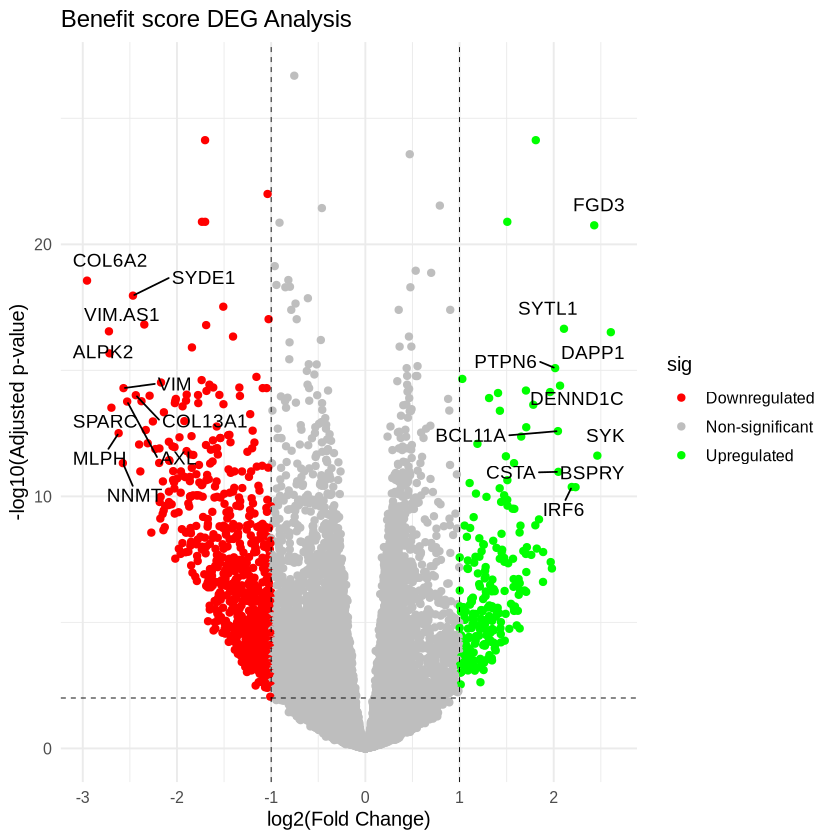

In [ ]:
print(P)

In [ ]:
# Identify top 10 upregulated and downregulated genes
top_up <- df %>%
  filter(sig == "Upregulated") %>%
  head(100)

top_down <- df %>%
  filter(sig == "Downregulated") %>%
  head(100)

top_genes <- bind_rows(top_up, top_down)
top_gene_list <- rownames(top_genes)

writeLines(top_gene_list, con = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/depMap_benefitScore_topDEG_28122025_optuna.txt')


In [ ]:
write.csv(res, file = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/depMap_benefitscore_deg_28122025_optuna.csv')